# Preprocessing - VW Golf / e-Golf

This notebook cleans and prepares the Golf dataset for merging


## Steps

Load merged CSV data
- 2. Inspect shape, schema, and missing values
- 3. Standardize column names and text fields
- 4. Convert numeric/date columns to proper types
- 5. Handle missing values with explicit rules
- 6. Remove duplicates and obvious data issues
- 7. Perform outlier checks and apply caps/filters
- 8. Create cleaned output for merging


## 1. Load Data


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
df_golf = pd.read_csv("/Users/riteshbhandari/Documents/Dokumentit – Ritesh - MacBook Pro/GitHub/DPPM/datasets/merged/dppm_vw_golf_e_golf.csv")


## 2. Inspect Data


In [72]:
df_golf.head()

,product_id,part_name,price,quality_grade,year,oem_number,engine_code,mileage,brand,model,category,subcategory,scrape_date,scrape_timestamp
0,63136980.0,"Contact roll Airbag - , e-",177.6,A2,2013-2020,FI02042722A,NaN,224000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2026-02-03T18:11:15+02:00
1,64390201.0,"Contact roll Airbag - , e-",177.6,A2,2013-2020,FI05351686A,NaN,272000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2026-02-03T18:11:15+02:00
2,58952159.0,"Contact roll Airbag - , e-",177.6,A2,2013-2020,FI27837687A,NaN,134000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2026-02-03T18:11:15+02:00
3,63225719.0,"Contact roll Airbag - , e-",177.6,A2,2013-2020,FI27837687A,NaN,253000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2026-02-03T18:11:15+02:00
4,64336640.0,"Contact roll Airbag - , e-",177.6,A2,2013-2020,FI09389104A,NaN,152000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2026-02-03T18:11:15+02:00


In [73]:
df_golf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4645 entries, 0 to 4644
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        3815 non-null   float64
 1   part_name         4645 non-null   object 
 2   price             4619 non-null   float64
 3   quality_grade     4618 non-null   object 
 4   year              4620 non-null   object 
 5   oem_number        3909 non-null   object 
 6   engine_code       68 non-null     object 
 7   mileage           3313 non-null   float64
 8   brand             4645 non-null   object 
 9   model             4645 non-null   object 
 10  category          4645 non-null   object 
 11  subcategory       4645 non-null   object 
 12  scrape_date       3815 non-null   object 
 13  scrape_timestamp  3815 non-null   object 
dtypes: float64(3), object(11)
memory usage: 508.2+ KB


In [74]:
df_golf.dtypes

product_id          float64
part_name            object
price               float64
quality_grade        object
year                 object
oem_number           object
engine_code          object
mileage             float64
brand                object
model                object
category             object
subcategory          object
scrape_date          object
scrape_timestamp     object
dtype: object

In [75]:
df_golf.isna().sum()

product_id           830
part_name              0
price                 26
quality_grade         27
year                  25
oem_number           736
engine_code         4577
mileage             1332
brand                  0
model                  0
category               0
subcategory            0
scrape_date          830
scrape_timestamp     830
dtype: int64

## 3. Drop Unneeded Columns


In [76]:
## deleting columns, not needed
df_golf = df_golf.drop(columns=['engine_code'])
df_golf = df_golf.drop(columns=['scrape_timestamp'])

## 4. Clean Price


In [77]:
# price column analysis
print(df_golf.shape)
print(df_golf['price'].dtype)
print(df_golf['price'].head())
print(df_golf['price'].describe())

(4645, 12)
float64
0    177.6
1    177.6
2    177.6
3    177.6
4    177.6
Name: price, dtype: float64
count    4619.000000
mean      240.626413
std       573.876519
min         5.900000
25%        47.400000
50%        84.000000
75%       204.900000
max      4343.500000
Name: price, dtype: float64


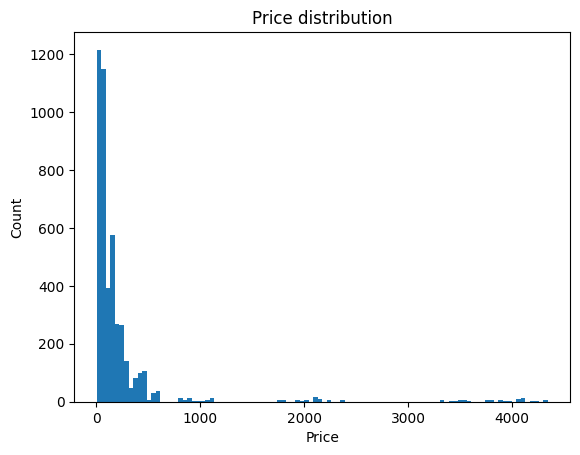

In [78]:
# price distribution check
plt.hist(df_golf["price"], bins=100)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution")
plt.show()

In [79]:
# delete missing price 
df_golf = df_golf.dropna(subset=['price'])

print(df_golf.shape)
print(df_golf['price'].describe())

(4619, 12)
count    4619.000000
mean      240.626413
std       573.876519
min         5.900000
25%        47.400000
50%        84.000000
75%       204.900000
max      4343.500000
Name: price, dtype: float64


## 5. Clean Year


In [80]:
# year column analysis
print(df_golf['year'].dtype)
print(df_golf['year'].head())
print(df_golf['year'].describe())
print(df_golf['year'].unique())

object
0    2013-2020
1    2013-2020
2    2013-2020
3    2013-2020
4    2013-2020
Name: year, dtype: object
count          4619
unique            7
top       2013-2020
freq           1869
Name: year, dtype: object
['2013-2020' '1992-1999' '2004-2009' '2020-2027' '2009-2013' '1998-2006'
 '1984-1991']


In [82]:
# splitting year data to end start and width of compatibility
df_golf[['year_start', 'year_end']] = df_golf['year'].str.split('-', expand=True)

df_golf['year_start'] = pd.to_numeric(df_golf['year_start'], errors='coerce')
df_golf['year_end'] = pd.to_numeric(df_golf['year_end'], errors='coerce')

df_golf['year_span'] = df_golf['year_end'] - df_golf['year_start']
df_golf['year_mid'] = (df_golf['year_start'] + df_golf['year_end']) / 2

print(df_golf[['year','year_start', 'year_end', 'year_span', 'year_mid']].head())

# remove original column
df_golf = df_golf.drop(columns=['year'])

        year  year_start  year_end  year_span  year_mid
0  2013-2020        2013      2020          7    2016.5
1  2013-2020        2013      2020          7    2016.5
2  2013-2020        2013      2020          7    2016.5
3  2013-2020        2013      2020          7    2016.5
4  2013-2020        2013      2020          7    2016.5


## 6. Convert Dates


In [83]:
# Converting datetime 
df_golf["scrape_date"] = pd.to_datetime(df_golf["scrape_date"], errors="coerce")
df_golf["scrape_date"].dtype

dtype('<M8[ns]')

## 7. Final Checks


In [84]:
# Final checks before merging
print(f" Mileage: {df_golf['mileage'].dtype}")
print(f" Quality Grade: {df_golf['quality_grade'].dtype}")
print(f" Missing Values: {df_golf.isna().sum()}")

 Mileage: float64
 Quality Grade: object
 Missing Values: product_id        829
part_name           0
price               0
quality_grade       2
oem_number        711
mileage          1307
brand               0
model               0
category            0
subcategory         0
scrape_date       829
year_start          0
year_end            0
year_span           0
year_mid            0
dtype: int64


In [85]:
# convert product id to integer
df_golf["product_id"] = df_golf["product_id"].astype("Int64")
df_golf.dtypes

product_id                Int64
part_name                object
price                   float64
quality_grade            object
oem_number               object
mileage                 float64
brand                    object
model                    object
category                 object
subcategory              object
scrape_date      datetime64[ns]
year_start                int64
year_end                  int64
year_span                 int64
year_mid                float64
dtype: object

## 8. Preview Output


In [86]:
df_golf.head()

,product_id,part_name,price,quality_grade,oem_number,mileage,brand,model,category,subcategory,scrape_date,year_start,year_end,year_span,year_mid
0,63136980,"Contact roll Airbag - , e-",177.6,A2,FI02042722A,224000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
1,64390201,"Contact roll Airbag - , e-",177.6,A2,FI05351686A,272000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
2,58952159,"Contact roll Airbag - , e-",177.6,A2,FI27837687A,134000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
3,63225719,"Contact roll Airbag - , e-",177.6,A2,FI27837687A,253000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5
4,64336640,"Contact roll Airbag - , e-",177.6,A2,FI09389104A,152000.0,VW,"Golf,-e_Golf",Airbag,Contact roll Airbag,2026-02-03,2013,2020,7,2016.5


## 9. Save Output


In [87]:
# save cleaned dataframe
df_golf.to_csv("cleaned_golf_data.csv", index=False)
